In [2]:
import polars as pl
from zipfile import ZipFile
import os
import matplotlib.pyplot as plt 
import skimage
from io import BytesIO
import torch
from torch import nn
from torchvision.transforms import ConvertImageDtype

In [3]:
pathy = '~/vault/morphem/dataset/sampling/multi_channel_chammi_metadata.csv'

In [4]:

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_width_chars(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_table_cell_list_len(-1)
pl.Config.set_fmt_str_lengths(1000)


polars.config.Config

In [5]:
pics = ZipFile(os.path.expanduser('~/scr/CHAMMI/chammi_train.zip'))

In [6]:
df = pl.read_csv(pathy)
images = list(df.filter(pl.col('storage.path').str.contains('/Allen/')).group_by('imaging.multi_channel_id'))

torch.Size([1, 238, 374])
torch.Size([238, 374])


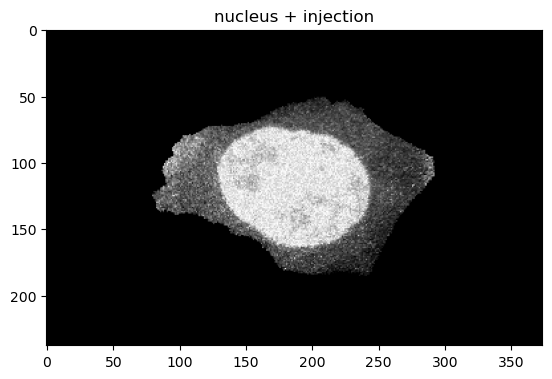

torch.Size([1, 238, 374])
torch.Size([238, 374])


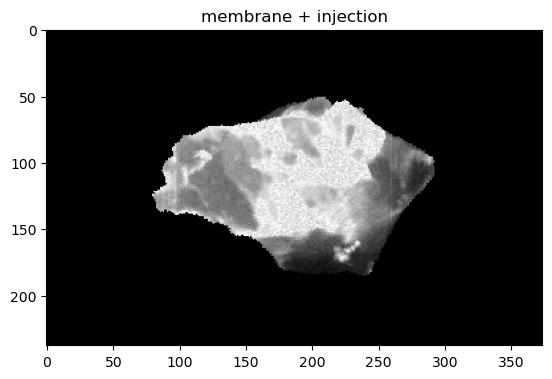

torch.Size([1, 238, 374])
torch.Size([238, 374])


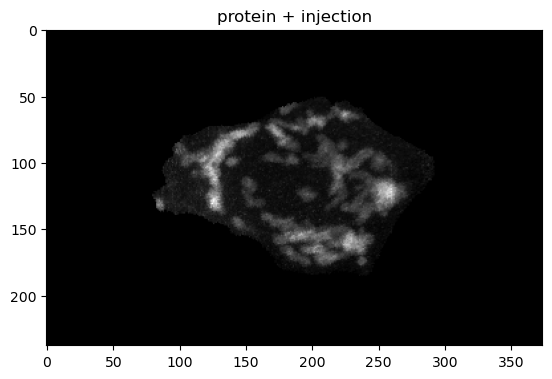

In [ ]:
class NoiseInjection(nn.Module):
    def __init__(self, low=200, high=255):
        super().__init__()
        self.low = low
        self.high = high

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        noise = torch.empty_like(x.to(torch.float32)).uniform_(self.low, self.high)
        return torch.where(x == 255, noise, x)
    
class SaturationNoiseInjector(nn.Module):
    def __init__(self, low=200, high=255):
        """
        Initialize the SaturationNoiseInjector module.
        
        Parameters:
            low (int): Lower bound for uniform noise values.
            high (int): Upper bound for uniform noise values.
        """
        super().__init__()
        self.low = low
        self.high = high

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply high-intensity noise injection to saturated pixels in a single-channel image.
        The function expects the input tensor to have the shape (1, H, W) with pixel intensities in the 0-255 range.

        Process:
          - Convert the input tensor to float32.
          - Generate noise drawn uniformly from [low, high] for each pixel.
          - Create a mask for saturated pixels (where the pixel value equals 255).
          - Zero-out saturated pixels and add the masked noise.

        Parameters:
            x (torch.Tensor): Input tensor of shape (1, H, W).
        
        Returns:
            torch.Tensor: The processed tensor with noise injected.
        """
        # Ensure input is in floating point for correct arithmetic
        x = x.to(torch.float32)
        # Since x has one channel, extract the channel as a 2D tensor (H, W)
        channel = x[0]
        
        # Generate noise with values uniformly drawn between self.low and self.high
        noise = torch.empty_like(channel).uniform_(self.low, self.high)
        # Create a mask of pixels that are saturated (value == 255)
        mask = (channel == 255).float()
        
        # Apply the mask to the noise to affect only the saturated pixels
        noise_masked = noise * mask
        
        # Remove the saturated pixels by setting them to zero
        channel[channel == 255] = 0
        
        # Add the masked noise to the channel
        channel = channel + noise_masked
        
        # Update the tensor with the modified channel
        x[0] = channel
        
        return x
    
inject = SaturationNoiseInjector()
# inject = NoiseInjection()
for row in images[4][1].iter_rows(named=True):
    pic = pics.read(row['storage.path'])
    np_pic = skimage.io.imread(BytesIO(pic))
    torch_pic = torch.from_numpy(np_pic).unsqueeze(0)
    # print(torch_pic.shape)
    np_pic = inject(torch_pic.to(torch.uint8)).squeeze().numpy()
    plt.imshow(np_pic, cmap='grey')
    plt.title(row['imaging.channel_type'] + " + injection")
    plt.show()